In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('coffee.csv')
df.head()

,Temperature,Coffee_Sales
0,14.981605,150.800298
1,38.028572,122.531718
2,29.279758,120.509181
3,23.946339,117.580908
4,6.240746,178.483961


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge, Lasso

In [5]:
# feature and target
x = df.iloc[:, 0:1]
y = df.iloc[:, -1]

# normalize
x = (x - x.mean()) / x.std()
y = (y - y.mean()) / y.std()

# split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=2)

# <span style = 'color:orange'>SCIKIT LEARN</span>

### Lasso Regression

Intercept:  -0.004807783855419634
Coef:  [-0.82818573]
R2 score:  0.8604254925749917


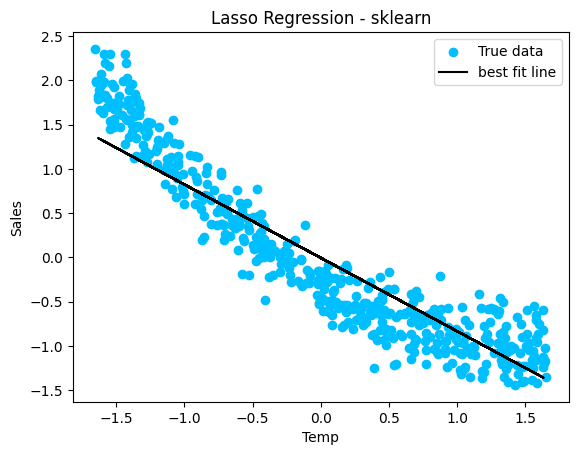

In [15]:
ls = Lasso(alpha=0.1)
ls.fit(x_train, y_train)
y_pred_ls = ls.predict(x_test)

print('Intercept: ',ls.intercept_)
print('Coef: ',ls.coef_)
print('R2 score: ',r2_score(y_test, y_pred_ls))


plt.scatter(x,y,color='deepskyblue', label = 'True data')
plt.plot(x_test, y_pred_ls, color = 'k', label = 'best fit line')
plt.xlabel('Temp')
plt.ylabel('Sales')
plt.title('Lasso Regression - sklearn')
plt.legend()
plt.show()

# <span style = 'color:orange'>CUSTOM CLASS</span>

In [32]:
class lasso_reg: 
    def __init__(self, alpha):
        self.alpha = alpha
        self.intercept_ = None
        self.coef_ = None
    
    def fit(self, x_train, y_train):
        num = 0
        den = 0 
        
        x_mean = x_train.mean()
        y_mean = y_train.mean()
        
        for i in range(x_train.shape[0]):
            num += (x_train.iloc[i] - x_mean) * (y_train.iloc[i] - y_mean)
            den += (x_train.iloc[i] - x_mean) ** 2
        
        # Use .item() to safely convert a single-element Series to a scalar
        # This addresses the FutureWarning directly
        num_val = num.item()
        den_val = den.item()
        
        if num_val > self.alpha / 2:
            self.coef_ = (num_val - self.alpha / 2) / den_val
        elif num_val < -self.alpha / 2:
            self.coef_ = (num_val + self.alpha / 2) / den_val
        else:
            self.coef_ = 0
        
        # Unwrapping means for the intercept calculation
        self.intercept_ = y_mean.item() - self.coef_ * x_mean.item()

        print('Intercept: ', self.intercept_)
        print('Coef: ', self.coef_)
    
    def predict(self, x_test):
        return self.intercept_ + (self.coef_ * x_test)

In [33]:
lr = lasso_reg(alpha=0.1)
lr.fit(x_train, y_train)
y_pred_cc = lr.predict(x_test)

print('r2 score: ',r2_score(y_test, y_pred_cc))

Intercept:  -0.0017085728549906497
Coef:  -0.9276850059816042
r2 score:  0.8805228904318813
